# Proprioceptive sensing — object stiffness estimation

The hand squeezes a grasped object with the four fingers held at constant stiffness
$k_{\rm hold}$ = {K_TIP_HOLD} N/m (clamping side).  The thumb alone sweeps through
increasing tip stiffness levels and the resulting position–force finite difference
estimates object compliance without external force sensors.

---

## Why $\Delta x / \Delta F$ recovers $C_O$

At equilibrium, the VMC spring force equals the object reaction force.  Taking the
finite difference between the gentle baseline ($k_1$) and each probe level ($k_2 > k_1$):

$$\Delta x_\text{thumb} = x(k_2) - x(k_1), \qquad \Delta F_\text{thumb} = F(k_2) - F(k_1)$$

$$C_O = \frac{\|\Delta x_\text{thumb}\|}{\|\Delta F_\text{thumb}\|}$$

The hand compliance cancels exactly; lower $C_O$ means stiffer object.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.join('../..'))
sys.path.insert(0, '.')
from hand_config import K_TIP_GENTLE, K_TIP_SWEEP, K_TIP_HOLD, OBJECTS, FINGERTIPS

OUTPUT_DIR = os.path.join('outputs', 'object_stiffness_hand')

K_TIP_GENTLE = float(K_TIP_GENTLE)
K_TIP_SWEEP  = [float(k) for k in K_TIP_SWEEP]
FINGERS = list(FINGERTIPS)

OBJECT_LABELS = ['Sphere', 'Sponge', 'Yarn']
OBJ_COLORS    = {'hard': '#D55E00', 'medium': '#E69F00', 'soft': '#56B4E9'}

def latest_run(object_name):
    path = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{object_name}.csv')
    return path if os.path.exists(path) else None

In [2]:
def steady_state(df):
    out = {}
    for k_tip, sub in df.groupby('k_tip_Npm'):
        per_finger = {}
        for f in FINGERS:
            pos  = sub[[f'tip_{f}_x_m', f'tip_{f}_y_m', f'tip_{f}_z_m']].median().to_numpy()
            ref  = sub[[f'ref_{f}_x_m', f'ref_{f}_y_m', f'ref_{f}_z_m']].median().to_numpy()
            F1   = sub[[f'force_1st_{f}_x_N', f'force_1st_{f}_y_N', f'force_1st_{f}_z_N']].median().to_numpy()
            per_finger[f] = dict(pos=pos, ref=ref, F1=F1)
        out[float(k_tip)] = per_finger
    return out


def thumb_compliance(ss):
    """C_O for the thumb at each sweep level; returns (k_levels, C_O_array)."""
    k_levels = sorted(k for k in ss if abs(k - K_TIP_GENTLE) > 1e-6)
    if K_TIP_GENTLE not in ss:
        return np.array(k_levels), np.full(len(k_levels), np.nan)
    pos_b = ss[K_TIP_GENTLE]['thumb']['pos']
    F_b   = ss[K_TIP_GENTLE]['thumb']['F1']
    C = []
    for k in k_levels:
        d_pos = ss[k]['thumb']['pos'] - pos_b
        d_F   = ss[k]['thumb']['F1']  - F_b
        nF    = np.linalg.norm(d_F)
        C.append(np.linalg.norm(d_pos) / nF if nF > 1e-12 else np.nan)
    return np.array(k_levels), np.array(C)


# Load latest run per object
data = {}
print('Loading data:')
for obj in OBJECTS:
    p = latest_run(obj)
    if p is None:
        print(f'  {obj:<10s}: no data')
        continue
    df = pd.read_csv(p)
    ss = steady_state(df)
    data[obj] = dict(df=df, ss=ss)
    print(f'  {obj:<10s}: k_tip levels {sorted(ss.keys())}')

Loading data:
  hard      : k_tip levels [20.0, 50.0, 100.0, 200.0]
  medium    : k_tip levels [20.0, 50.0, 100.0, 200.0]
  soft      : k_tip levels [20.0, 50.0, 100.0, 200.0]


## Thumb object compliance $C_O$ vs $k_{tip}$

$C_O^{\rm thumb}(k) = \|\Delta x_{\rm thumb}\| / \|\Delta F_{\rm thumb}\|$ for each sweep level.
Lower = stiffer object.

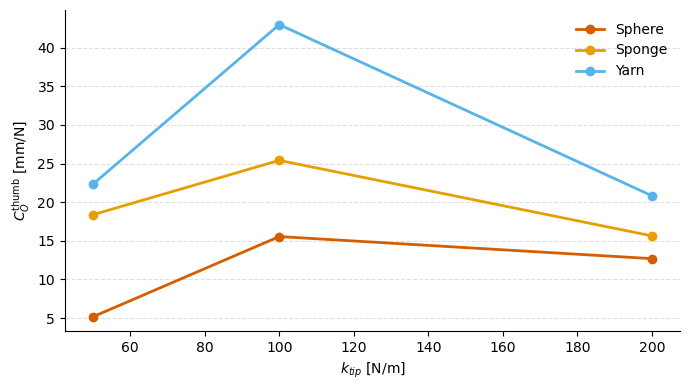

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

for obj in OBJECTS:
    if obj not in data:
        continue
    k_arr, C_arr = thumb_compliance(data[obj]['ss'])
    oi   = OBJECTS.index(obj)
    name = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
    ax.plot(k_arr, C_arr * 1e3, marker='o', label=name, color=OBJ_COLORS[obj], lw=2)

ax.set_xlabel(r'$k_{tip}$ [N/m]')
ax.set_ylabel(r'$C_O^{\mathrm{thumb}}$ [mm/N]')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_compliance_sweep.pdf'), bbox_inches='tight')
plt.show()

## Thumb tip displacement $\|\Delta x_{\rm thumb}\|$ vs $k_{tip}$

Displacement of the thumb tip relative to the gentle baseline position.

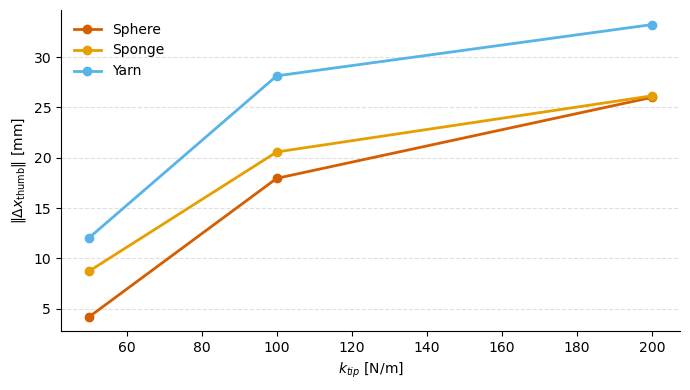

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

for obj in OBJECTS:
    if obj not in data:
        continue
    ss   = data[obj]['ss']
    if K_TIP_GENTLE not in ss:
        continue
    pos_b    = ss[K_TIP_GENTLE]['thumb']['pos']
    k_levels = sorted(k for k in ss if abs(k - K_TIP_GENTLE) > 1e-6)
    disps    = [np.linalg.norm(ss[k]['thumb']['pos'] - pos_b) * 1e3 for k in k_levels]
    oi   = OBJECTS.index(obj)
    name = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
    ax.plot(k_levels, disps, marker='o', label=name, color=OBJ_COLORS[obj], lw=2)

ax.set_xlabel(r'$k_{tip}$ [N/m]')
ax.set_ylabel(r'$\|\Delta x_{\mathrm{thumb}}\|$ [mm]')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_displacement_sweep.pdf'), bbox_inches='tight')
plt.show()

## Thumb contact force $\|\Delta F_{\rm thumb}\|$ vs $k_{tip}$

Force change relative to the gentle baseline. Larger $\|\Delta F\|$ means firmer contact and a more reliable $C_O$ estimate.

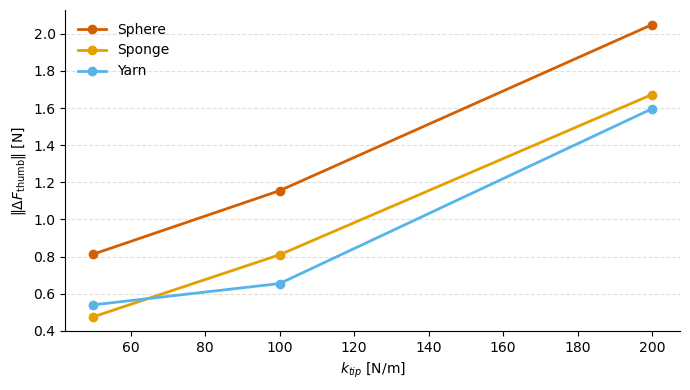

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

for obj in OBJECTS:
    if obj not in data:
        continue
    ss   = data[obj]['ss']
    if K_TIP_GENTLE not in ss:
        continue
    F_b      = ss[K_TIP_GENTLE]['thumb']['F1']
    k_levels = sorted(k for k in ss if abs(k - K_TIP_GENTLE) > 1e-6)
    forces   = [np.linalg.norm(ss[k]['thumb']['F1'] - F_b) for k in k_levels]
    oi   = OBJECTS.index(obj)
    name = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
    ax.plot(k_levels, forces, marker='o', label=name, color=OBJ_COLORS[obj], lw=2)

ax.set_xlabel(r'$k_{tip}$ [N/m]')
ax.set_ylabel(r'$\|\Delta F_{\mathrm{thumb}}\|$ [N]')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_force_sweep.pdf'), bbox_inches='tight')
plt.show()

## Object classification by thumb compliance

$C_O^{\rm thumb}$ at the highest $k_{tip}$ level ranks the objects: lower = stiffer.

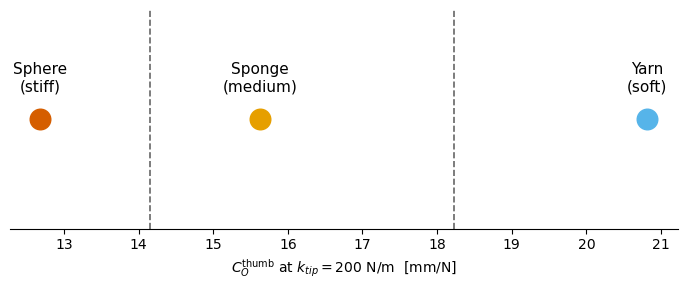

Object classification (thumb C_O):
  Sphere      C_O = 12.68 mm/N  -->  stiff
  Sponge      C_O = 15.63 mm/N  -->  medium
  Yarn        C_O = 20.82 mm/N  -->  soft


In [6]:
K_TOP = max(K_TIP_SWEEP)

C_O_thumb = {}
for obj in OBJECTS:
    if obj not in data:
        continue
    ss = data[obj]['ss']
    if K_TOP not in ss or K_TIP_GENTLE not in ss:
        continue
    d_pos = ss[K_TOP]['thumb']['pos'] - ss[K_TIP_GENTLE]['thumb']['pos']
    d_F   = ss[K_TOP]['thumb']['F1']  - ss[K_TIP_GENTLE]['thumb']['F1']
    nF    = np.linalg.norm(d_F)
    if nF > 1e-12:
        C_O_thumb[obj] = float(np.linalg.norm(d_pos) / nF)

if not C_O_thumb:
    print('No data available -- skipping object classification.')
else:
    sorted_objs    = sorted(C_O_thumb, key=C_O_thumb.get)
    cluster_labels = {sorted_objs[i]: lbl
                      for i, lbl in enumerate(['stiff', 'medium', 'soft'][:len(sorted_objs)])}

    vals       = [C_O_thumb[o] for o in sorted_objs]
    thresholds = [(vals[i] + vals[i+1]) / 2 for i in range(len(vals) - 1)]

    fig, ax = plt.subplots(figsize=(7, 3))
    for obj in sorted_objs:
        oi    = OBJECTS.index(obj)
        name  = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        lbl   = cluster_labels[obj]
        ax.scatter([C_O_thumb[obj] * 1e3], [0], color=OBJ_COLORS[obj], s=220, zorder=5)
        ax.annotate(f'{name}\n({lbl})', (C_O_thumb[obj] * 1e3, 0),
                    textcoords='offset points', xytext=(0, 20),
                    ha='center', fontsize=11)
    for thr in thresholds:
        ax.axvline(thr * 1e3, color='0.4', lw=1.2, linestyle='--')

    ax.set_xlabel(r'$C_O^{\mathrm{thumb}}$ at $k_{tip}=' + f'{K_TOP:.0f}$' + r' N/m  [mm/N]')
    ax.set_yticks([])
    ax.spines[['left', 'top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'object_classification.pdf'), bbox_inches='tight')
    plt.show()

    print('Object classification (thumb C_O):')
    for obj in sorted_objs:
        oi   = OBJECTS.index(obj)
        name = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        print(f'  {name:<10s}  C_O = {C_O_thumb[obj]*1e3:.2f} mm/N  -->  {cluster_labels[obj]}')